# Fruit or Animal Classifier

This notebook is a guided AI analytics walkthrough for Microsoft Visual Studio Code and Jupyter.

The goal is to build and understand a program that looks at a picture and predicts whether it is an `animal` or a `fruit`.

By the end, you will have seen:

- how image examples become a labelled dataset
- why we split data into training and testing groups
- how pictures are converted into numbers
- why a random forest is a suitable first model for a one-day project
- how to read accuracy, a confusion matrix, and confidence scores
- how to run the model on images outside the training folder

## Goal

We are building a tiny supervised learning system.

Supervised learning means we show the computer examples where we already know the answer. The model looks for patterns in those examples, then tries to use those patterns on new images.

For this exercise, the known answers are the folder names:

- images in `data/images/animal` are labelled `animal`
- images in `data/images/fruit` are labelled `fruit`

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image, ImageOps

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from common import IMAGE_SIZE, extract_features, image_files, load_rgb_image, make_feature_matrix

DATA_DIR = PROJECT_ROOT / "data/images"
DEMO_DIR = PROJECT_ROOT / "data/demo_inputs"
MODEL_PATH = PROJECT_ROOT / "models/fruit_animal_classifier.joblib"
REPORT_DIR = PROJECT_ROOT / "reports"

CLASS_COLORS = {
    "animal": "#2f6f6f",
    "fruit": "#d28b26",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "text.color": "#222222",
    "font.size": 10,
})

print("Project folder detected.")

Project folder detected.


## Parameters You Can Change

These parameters are near the top so students can experiment without hunting through the code.

Start with the defaults first. After the notebook works, try changing one value at a time.

In [2]:
TARGET_PER_CLASS = 150      # Images to collect for each class when rebuilding the dataset
TEST_SIZE = 0.20            # 0.20 means 20% testing and 80% training
RANDOM_STATE = 7            # Controls the train/test split so results are repeatable
MODEL_RANDOM_STATE = 0      # Controls the random forest so training is repeatable
N_ESTIMATORS = 500          # Number of decision trees in the random forest

REBUILD_DATASET = False     # Set True to download a fresh dataset
RETRAIN_MODEL = False       # Set True after changing TEST_SIZE or N_ESTIMATORS

parameter_table = pd.DataFrame(
    [
        ("TARGET_PER_CLASS", TARGET_PER_CLASS, "How many fruit and animal images to collect"),
        ("TEST_SIZE", TEST_SIZE, "Fraction of data held back for testing"),
        ("RANDOM_STATE", RANDOM_STATE, "Repeatable train/test split"),
        ("MODEL_RANDOM_STATE", MODEL_RANDOM_STATE, "Repeatable model training"),
        ("N_ESTIMATORS", N_ESTIMATORS, "How many trees vote in the random forest"),
        ("REBUILD_DATASET", REBUILD_DATASET, "Download new images if True"),
        ("RETRAIN_MODEL", RETRAIN_MODEL, "Train again if True"),
    ],
    columns=["parameter", "value", "meaning"],
)
display(parameter_table)

,parameter,value,meaning
0,TARGET_PER_CLASS,150,How many fruit and animal images to collect
1,TEST_SIZE,0.2,Fraction of data held back for testing
2,RANDOM_STATE,7,Repeatable train/test split
3,MODEL_RANDOM_STATE,0,Repeatable model training
4,N_ESTIMATORS,500,How many trees vote in the random forest
5,REBUILD_DATASET,False,Download new images if True
6,RETRAIN_MODEL,False,Train again if True


## The Whole Pipeline

This diagram shows the path from raw pictures to a prediction on a new picture.

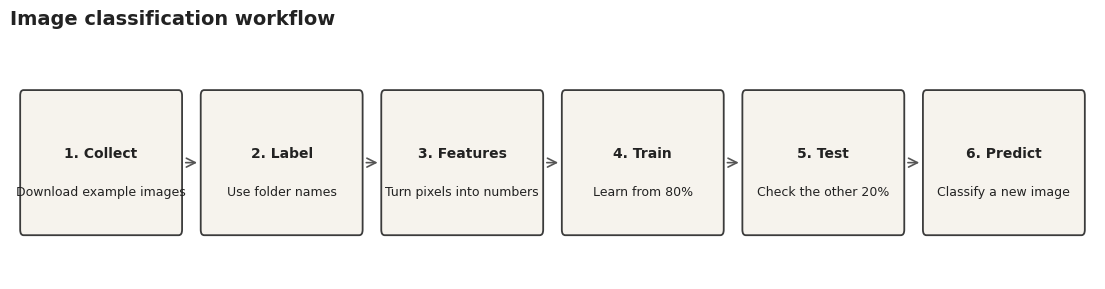

In [3]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

steps = [
    ("1. Collect", "Download example images"),
    ("2. Label", "Use folder names"),
    ("3. Features", "Turn pixels into numbers"),
    ("4. Train", "Learn from 80%"),
    ("5. Test", "Check the other 20%"),
    ("6. Predict", "Classify a new image"),
]

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.set_axis_off()

box_width = 1.85
gap = 0.28
for index, (title, subtitle) in enumerate(steps):
    x = index * (box_width + gap)
    box = FancyBboxPatch(
        (x, 0.35),
        box_width,
        1.0,
        boxstyle="round,pad=0.03,rounding_size=0.04",
        linewidth=1.3,
        edgecolor="#3b3b3b",
        facecolor="#f6f3ed",
    )
    ax.add_patch(box)
    ax.text(x + box_width / 2, 0.92, title, ha="center", va="center", weight="bold")
    ax.text(x + box_width / 2, 0.64, subtitle, ha="center", va="center", fontsize=9)
    if index < len(steps) - 1:
        arrow = FancyArrowPatch(
            (x + box_width + 0.04, 0.85),
            (x + box_width + gap - 0.04, 0.85),
            arrowstyle="->",
            mutation_scale=16,
            linewidth=1.2,
            color="#555555",
        )
        ax.add_patch(arrow)

ax.set_xlim(-0.15, len(steps) * (box_width + gap) - gap + 0.15)
ax.set_ylim(0, 1.8)
ax.set_title("Image classification workflow", loc="left", fontsize=14, weight="bold")
plt.show()

## Build Or Reuse The Assets

The repository already includes a dataset and trained model, so normal classroom use does not need to download anything.

This cell only downloads or trains when files are missing, or when you deliberately set `REBUILD_DATASET` or `RETRAIN_MODEL` to `True`.

In [4]:
def count_images(folder):
    return len(image_files(folder)) if folder.exists() else 0

fruit_count = count_images(DATA_DIR / "fruit")
animal_count = count_images(DATA_DIR / "animal")
dataset_ready = fruit_count >= TARGET_PER_CLASS and animal_count >= TARGET_PER_CLASS
model_ready = MODEL_PATH.exists()

if REBUILD_DATASET or not dataset_ready:
    print("Building dataset. This needs internet access and can take several minutes.")
    subprocess.run(
        [
            sys.executable,
            "src/download_keyword_dataset.py",
            "--output-dir",
            str(DATA_DIR.relative_to(PROJECT_ROOT)),
            "--demo-dir",
            str(DEMO_DIR.relative_to(PROJECT_ROOT)),
            "--target-per-class",
            str(TARGET_PER_CLASS),
            "--clean",
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )
else:
    print(f"Dataset already present: {fruit_count} fruit images and {animal_count} animal images.")

if RETRAIN_MODEL or not model_ready:
    print("Training model.")
    subprocess.run(
        [
            sys.executable,
            "src/train_model.py",
            "--data-dir",
            str(DATA_DIR.relative_to(PROJECT_ROOT)),
            "--model-path",
            str(MODEL_PATH.relative_to(PROJECT_ROOT)),
            "--report-dir",
            str(REPORT_DIR.relative_to(PROJECT_ROOT)),
            "--test-size",
            str(TEST_SIZE),
            "--random-state",
            str(RANDOM_STATE),
            "--model-random-state",
            str(MODEL_RANDOM_STATE),
            "--n-estimators",
            str(N_ESTIMATORS),
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )
else:
    print(f"Model already present: {MODEL_PATH.relative_to(PROJECT_ROOT)}")

Dataset already present: 150 fruit images and 150 animal images.
Model already present: models/fruit_animal_classifier.joblib


## Step 1: Look At The Data

Before training a model, inspect the data. This is a basic analytics habit: do not trust a dataset until you have looked at examples and checked simple counts.

In [5]:
def keyword_from_filename(path):
    parts = Path(path).stem.split("_", 2)
    return parts[2] if len(parts) == 3 else "unknown"


def image_stats(path, class_name):
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        width, height = image.size
        sample = np.asarray(image.resize((48, 48)), dtype=np.float32) / 255.0
    return {
        "path": str(Path(path).relative_to(PROJECT_ROOT)),
        "class": class_name,
        "keyword": keyword_from_filename(path),
        "width": width,
        "height": height,
        "aspect_ratio": round(width / height, 3),
        "brightness": float(sample.mean()),
        "contrast": float(sample.std()),
    }


records = []
for class_name in ["animal", "fruit"]:
    for path in image_files(DATA_DIR / class_name):
        records.append(image_stats(path, class_name))

images_df = pd.DataFrame(records)

summary_df = (
    images_df.groupby("class")
    .agg(
        images=("path", "count"),
        keywords=("keyword", "nunique"),
        average_brightness=("brightness", "mean"),
        average_contrast=("contrast", "mean"),
        min_width=("width", "min"),
        max_width=("width", "max"),
    )
    .round(3)
    .reset_index()
)

display(summary_df)
display(images_df.head(8))

,class,images,keywords,average_brightness,average_contrast,min_width,max_width
0,animal,150,12,0.410,0.202,360,360
1,fruit,150,12,0.462,0.230,360,360


,path,class,keyword,width,height,aspect_ratio,brightness,contrast
0,data/images/animal/animal_001_cat.jpg,animal,cat,360,260,1.385,0.405982,0.167277
1,data/images/animal/animal_002_dog.jpg,animal,dog,360,260,1.385,0.411639,0.255074
2,data/images/animal/animal_003_horse.jpg,animal,horse,360,260,1.385,0.452895,0.225521
3,data/images/animal/animal_004_cow.jpg,animal,cow,360,260,1.385,0.395395,0.137291
4,data/images/animal/animal_005_elephant.jpg,animal,elephant,360,260,1.385,0.506881,0.181063
5,data/images/animal/animal_006_bird.jpg,animal,bird,360,260,1.385,0.503703,0.255447
6,data/images/animal/animal_007_fox.jpg,animal,fox,360,260,1.385,0.425099,0.143646
7,data/images/animal/animal_008_sheep.jpg,animal,sheep,360,260,1.385,0.214696,0.180099


### Sample Images

A model can only learn from the examples it is given. Looking at samples helps us spot noisy images, wrong labels, or missing variety.

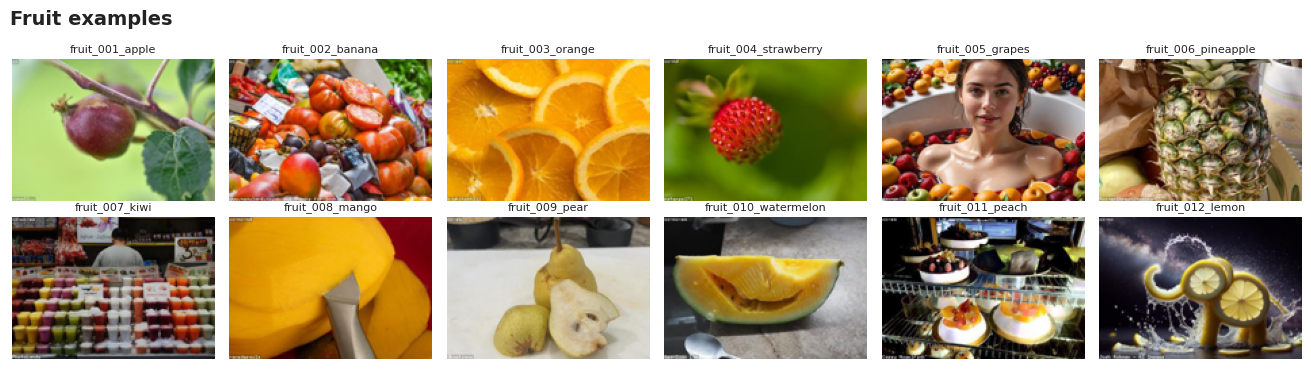

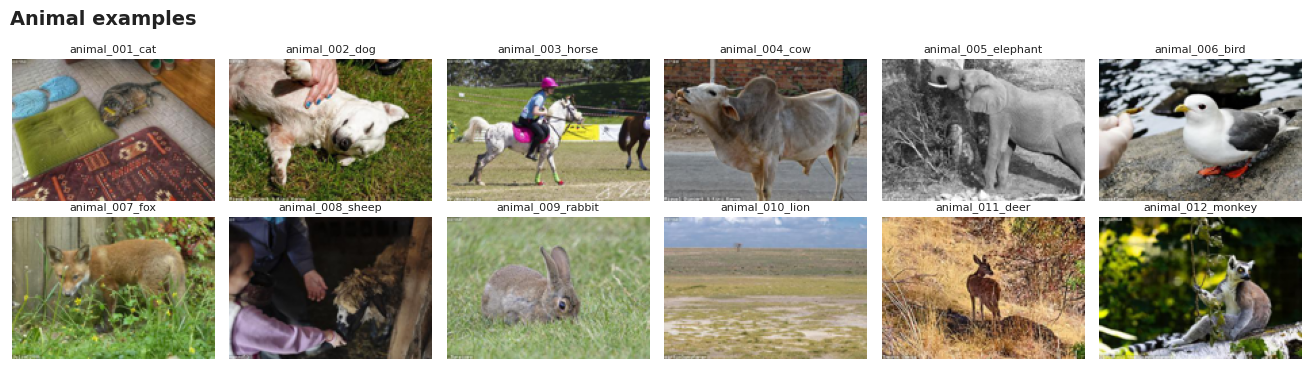

In [6]:
def show_gallery(paths, title, columns=6, image_size=(150, 105)):
    paths = list(paths)
    rows = int(np.ceil(len(paths) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 2.2, rows * 1.9))
    axes = np.array(axes).reshape(rows, columns)
    for ax in axes.ravel():
        ax.set_axis_off()
    for ax, path in zip(axes.ravel(), paths):
        with Image.open(path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            ax.imshow(image.resize(image_size))
        ax.set_title(Path(path).stem, fontsize=8)
    fig.suptitle(title, x=0.01, ha="left", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


show_gallery(image_files(DATA_DIR / "fruit")[:12], "Fruit examples")
show_gallery(image_files(DATA_DIR / "animal")[:12], "Animal examples")

## Step 2: Dataset Diagnostics

These charts answer simple but important questions:

- Are the classes balanced?
- Which keywords produced the examples?
- Do the images have similar sizes?
- Do brightness and contrast differ by class?

These checks introduce the idea of data quality before we talk about model quality.

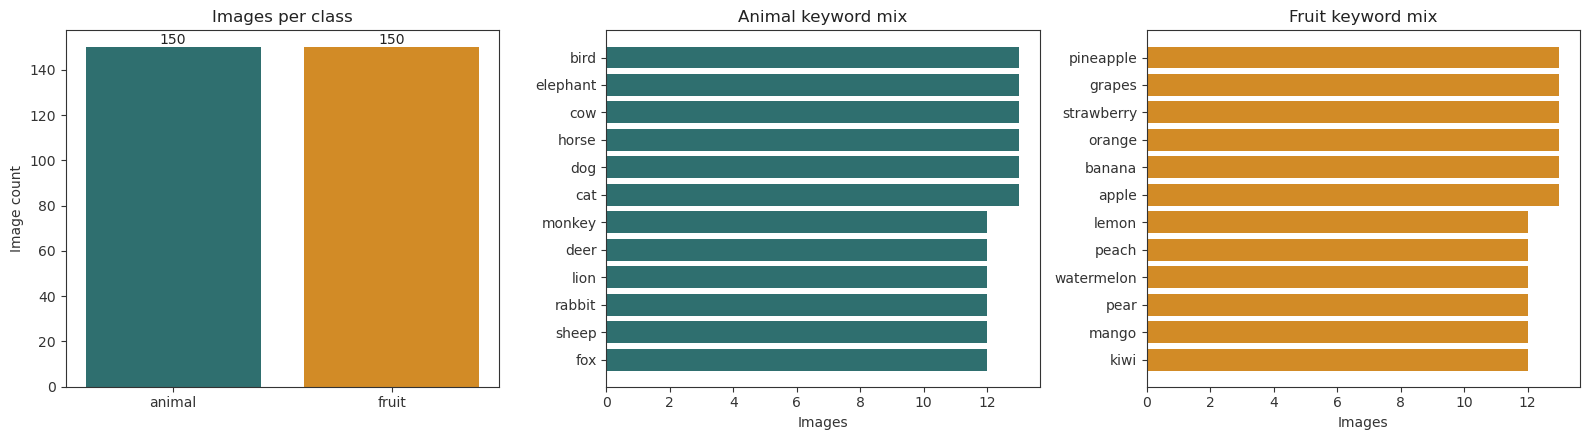

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

class_counts = images_df["class"].value_counts().reindex(["animal", "fruit"])
axes[0].bar(
    class_counts.index,
    class_counts.values,
    color=[CLASS_COLORS[label] for label in class_counts.index],
)
axes[0].set_title("Images per class")
axes[0].set_ylabel("Image count")
axes[0].bar_label(axes[0].containers[0])

for class_name, ax in zip(["animal", "fruit"], axes[1:]):
    keyword_counts = (
        images_df[images_df["class"] == class_name]["keyword"]
        .value_counts()
        .sort_values()
    )
    ax.barh(keyword_counts.index, keyword_counts.values, color=CLASS_COLORS[class_name])
    ax.set_title(f"{class_name.title()} keyword mix")
    ax.set_xlabel("Images")

plt.tight_layout()
plt.show()

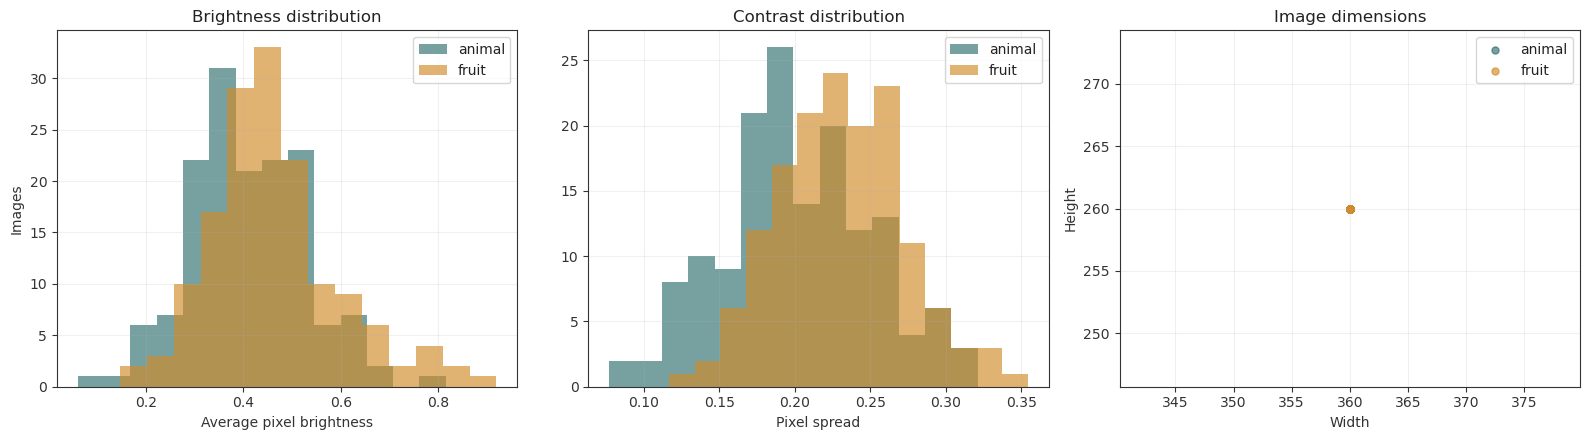

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for class_name in ["animal", "fruit"]:
    subset = images_df[images_df["class"] == class_name]
    axes[0].hist(
        subset["brightness"],
        bins=14,
        alpha=0.65,
        label=class_name,
        color=CLASS_COLORS[class_name],
    )
    axes[1].hist(
        subset["contrast"],
        bins=14,
        alpha=0.65,
        label=class_name,
        color=CLASS_COLORS[class_name],
    )
    axes[2].scatter(
        subset["width"],
        subset["height"],
        s=26,
        alpha=0.65,
        label=class_name,
        color=CLASS_COLORS[class_name],
    )

axes[0].set_title("Brightness distribution")
axes[0].set_xlabel("Average pixel brightness")
axes[0].set_ylabel("Images")
axes[1].set_title("Contrast distribution")
axes[1].set_xlabel("Pixel spread")
axes[2].set_title("Image dimensions")
axes[2].set_xlabel("Width")
axes[2].set_ylabel("Height")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

## Step 3: Train And Test Split

We do not test the model on the exact same images it learned from.

The split is:

- training data: the examples used to learn patterns
- testing data: examples held back until the end, used to check whether the model generalises

With `TEST_SIZE = 0.20`, the project trains on 80% of the images and tests on 20%.

,split,images
0,training,240
1,testing,60


class,animal,fruit
split,,
testing,30,30
training,120,120


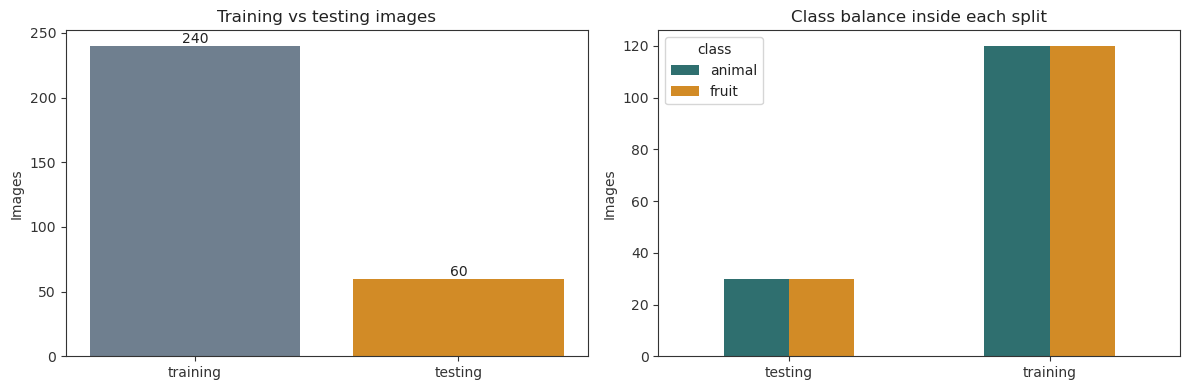

In [9]:
split_path = REPORT_DIR / "train_test_split.json"
split_info = json.loads(split_path.read_text(encoding="utf-8"))

split_counts = pd.DataFrame(
    [
        {"split": "training", "images": split_info["train_count"]},
        {"split": "testing", "images": split_info["test_count"]},
    ]
)
display(split_counts)

def split_class_counts(paths, split_name):
    rows = []
    for path in paths:
        rows.append({"split": split_name, "class": Path(path).parent.name})
    return rows

split_class_df = pd.DataFrame(
    split_class_counts(split_info["train_files"], "training")
    + split_class_counts(split_info["test_files"], "testing")
)
split_class_pivot = (
    split_class_df.value_counts(["split", "class"])
    .rename("images")
    .reset_index()
    .pivot(index="split", columns="class", values="images")
    .fillna(0)
    .astype(int)
)
display(split_class_pivot)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(split_counts["split"], split_counts["images"], color=["#6f7f8f", "#d28b26"])
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title("Training vs testing images")
axes[0].set_ylabel("Images")

split_class_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=[CLASS_COLORS.get(column, "#777777") for column in split_class_pivot.columns],
)
axes[1].set_title("Class balance inside each split")
axes[1].set_ylabel("Images")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Step 4: Convert Images Into Numbers

Machine learning models do not understand a JPEG file directly.

This project turns each image into a feature vector. A feature is a number that describes something about the image.

The completed implementation uses:

- colour histograms: how much red, green, and blue appear at different strengths
- average colour: the typical red, green, and blue values
- colour spread: how varied the colours are
- a tiny 16 by 16 thumbnail: a rough sketch of the image layout

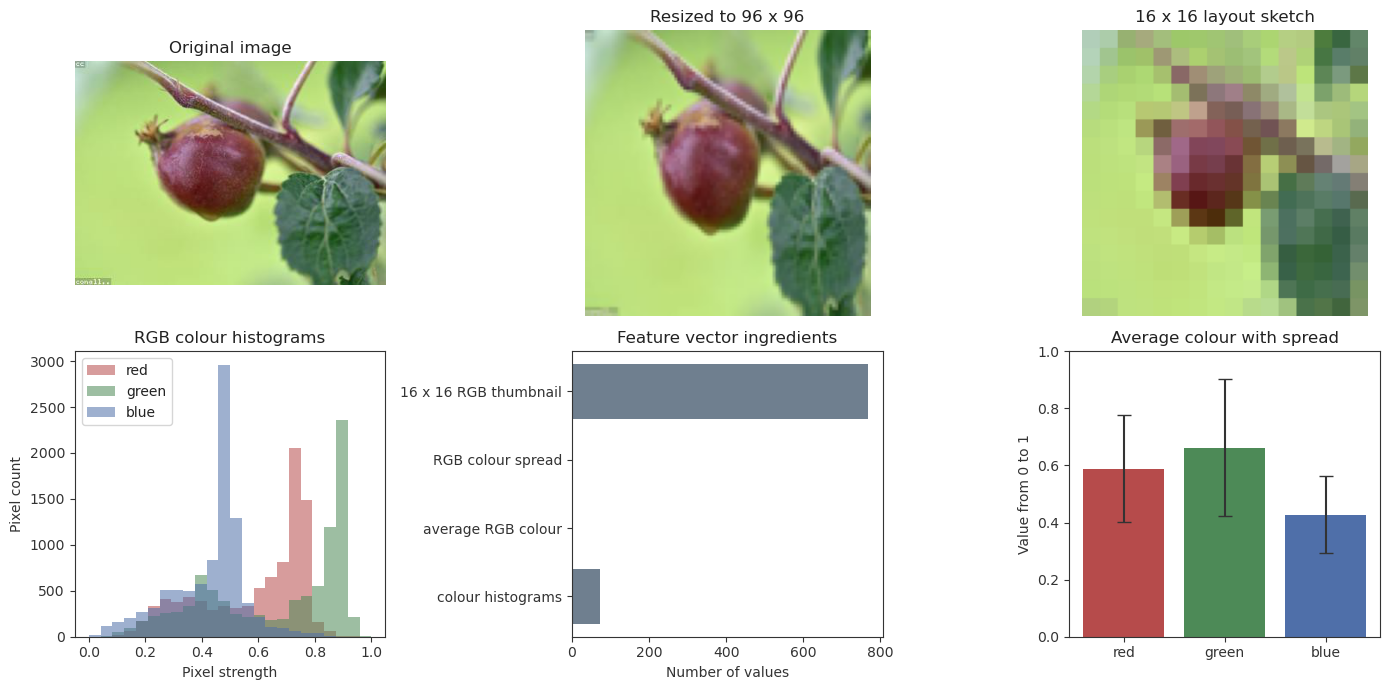

,feature group,numbers
0,colour histograms,72
1,average RGB colour,3
2,RGB colour spread,3
3,16 x 16 RGB thumbnail,768


**Feature vector length:** 846 numbers for one image.

In [10]:
SAMPLE_IMAGE_PATH = DATA_DIR / "fruit/fruit_001_apple.jpg"
if not SAMPLE_IMAGE_PATH.exists():
    SAMPLE_IMAGE_PATH = image_files(DATA_DIR / "fruit")[0]

original = Image.open(SAMPLE_IMAGE_PATH)
original = ImageOps.exif_transpose(original).convert("RGB")
resized = load_rgb_image(SAMPLE_IMAGE_PATH)
tiny = resized.resize((16, 16))
feature_vector = extract_features(SAMPLE_IMAGE_PATH)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes[0, 0].imshow(original)
axes[0, 0].set_title("Original image")
axes[0, 0].set_axis_off()

axes[0, 1].imshow(resized)
axes[0, 1].set_title(f"Resized to {IMAGE_SIZE[0]} x {IMAGE_SIZE[1]}")
axes[0, 1].set_axis_off()

axes[0, 2].imshow(tiny.resize((160, 160), Image.Resampling.NEAREST))
axes[0, 2].set_title("16 x 16 layout sketch")
axes[0, 2].set_axis_off()

pixels = np.asarray(resized, dtype=np.float32) / 255.0
channel_info = [("red", 0, "#b64b4b"), ("green", 1, "#4d8a57"), ("blue", 2, "#4f6fa9")]
for name, channel, color in channel_info:
    axes[1, 0].hist(
        pixels[:, :, channel].ravel(),
        bins=24,
        range=(0.0, 1.0),
        alpha=0.55,
        label=name,
        color=color,
    )
axes[1, 0].set_title("RGB colour histograms")
axes[1, 0].set_xlabel("Pixel strength")
axes[1, 0].set_ylabel("Pixel count")
axes[1, 0].legend()

average_colour = pixels.mean(axis=(0, 1))
colour_spread = pixels.std(axis=(0, 1))
feature_parts = pd.DataFrame(
    [
        {"feature group": "colour histograms", "numbers": 24 * 3},
        {"feature group": "average RGB colour", "numbers": 3},
        {"feature group": "RGB colour spread", "numbers": 3},
        {"feature group": "16 x 16 RGB thumbnail", "numbers": 16 * 16 * 3},
    ]
)
axes[1, 1].barh(feature_parts["feature group"], feature_parts["numbers"], color="#6f7f8f")
axes[1, 1].set_title("Feature vector ingredients")
axes[1, 1].set_xlabel("Number of values")

axes[1, 2].bar(["red", "green", "blue"], average_colour, color=["#b64b4b", "#4d8a57", "#4f6fa9"])
axes[1, 2].errorbar(
    ["red", "green", "blue"],
    average_colour,
    yerr=colour_spread,
    fmt="none",
    ecolor="#333333",
    capsize=5,
)
axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_title("Average colour with spread")
axes[1, 2].set_ylabel("Value from 0 to 1")

plt.tight_layout()
plt.show()

display(feature_parts)
display(Markdown(f"**Feature vector length:** {len(feature_vector)} numbers for one image."))

## Step 5: Choose The Model

For this one-day project, we use a `RandomForestClassifier`.

A random forest is a group of decision trees. Each tree votes for a class, and the forest combines the votes.

Why this is a good classroom choice:

- it works with simple numeric features
- it trains quickly on a laptop
- it does not need a GPU
- it gives useful probability scores for each class

For a production image classifier, a convolutional neural network or transfer learning model would usually be stronger. For a first Python AI project, random forest is easier to understand and debug.

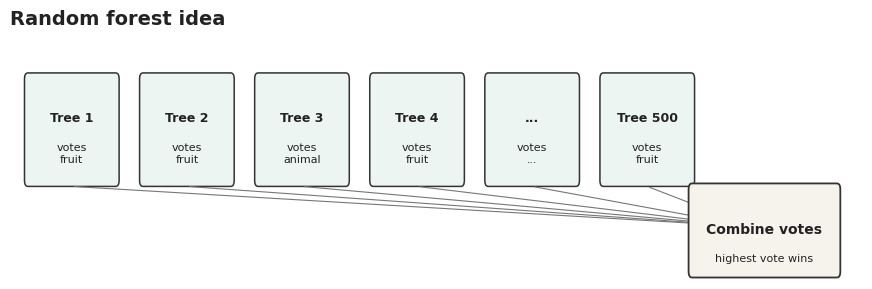

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_axis_off()

tree_labels = ["Tree 1", "Tree 2", "Tree 3", "Tree 4", "...", f"Tree {N_ESTIMATORS}"]
tree_votes = ["fruit", "fruit", "animal", "fruit", "...", "fruit"]

for index, (tree_label, vote) in enumerate(zip(tree_labels, tree_votes)):
    x = index * 1.35
    box = FancyBboxPatch(
        (x, 0.65),
        1.05,
        0.7,
        boxstyle="round,pad=0.03,rounding_size=0.04",
        linewidth=1.1,
        edgecolor="#333333",
        facecolor="#edf5f2",
    )
    ax.add_patch(box)
    ax.text(x + 0.525, 1.08, tree_label, ha="center", va="center", weight="bold", fontsize=9)
    ax.text(x + 0.525, 0.84, f"votes\n{vote}", ha="center", va="center", fontsize=8)
    ax.add_patch(
        FancyArrowPatch(
            (x + 0.525, 0.62),
            (8.5, 0.35),
            arrowstyle="->",
            mutation_scale=10,
            linewidth=0.8,
            color="#777777",
        )
    )

vote_box = FancyBboxPatch(
    (7.8, 0.05),
    1.7,
    0.55,
    boxstyle="round,pad=0.04,rounding_size=0.04",
    linewidth=1.3,
    edgecolor="#333333",
    facecolor="#f6f3ed",
)
ax.add_patch(vote_box)
ax.text(8.65, 0.33, "Combine votes", ha="center", va="center", weight="bold")
ax.text(8.65, 0.14, "highest vote wins", ha="center", va="center", fontsize=8)

ax.set_xlim(-0.2, 9.8)
ax.set_ylim(0, 1.65)
ax.set_title("Random forest idea", loc="left", fontsize=14, weight="bold")
plt.show()

## Step 6: Inspect The Trained Model

The model file stores the trained random forest plus the label names and feature settings needed for prediction.

In [12]:
package = joblib.load(MODEL_PATH)
model = package["model"]
class_names = package["class_names"]

model_info = pd.DataFrame(
    [
        ("classes", ", ".join(class_names)),
        ("image size", str(package.get("image_size", IMAGE_SIZE))),
        ("feature version", package.get("feature_version", "unknown")),
        ("decision trees", package.get("n_estimators", getattr(model, "n_estimators", "unknown"))),
        ("test size", package.get("test_size", split_info.get("test_size", "unknown"))),
    ],
    columns=["item", "value"],
)
display(model_info)

,item,value
0,classes,"animal, fruit"
1,image size,"(96, 96)"
2,feature version,1
3,decision trees,500
4,test size,0.2


## Step 7: Evaluate The Model

Accuracy tells us how many test images were classified correctly.

A confusion matrix shows which mistakes were made. Rows are the real labels. Columns are the predicted labels.

Accuracy: 0.767

              precision    recall  f1-score   support

      animal       0.77      0.77      0.77        30
       fruit       0.77      0.77      0.77        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



,actual,animal,fruit
0,animal,23,7
1,fruit,7,23


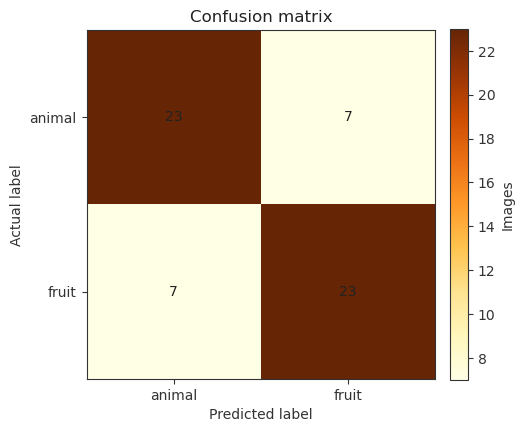

In [13]:
print((REPORT_DIR / "test_results.txt").read_text(encoding="utf-8"))

confusion_df = pd.read_csv(REPORT_DIR / "confusion_matrix.csv")
actual_column = confusion_df.columns[0]
confusion_df = confusion_df.rename(columns={actual_column: "actual"})
display(confusion_df)

matrix = confusion_df[class_names].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
image = ax.imshow(matrix, cmap="YlOrBr")
ax.set_xticks(range(len(class_names)), labels=class_names)
ax.set_yticks(range(len(class_names)), labels=class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_title("Confusion matrix")

for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        ax.text(column, row, str(matrix[row, column]), ha="center", va="center", color="#222222")

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Images")
plt.tight_layout()
plt.show()

### Precision, Recall, And F1 Score

These are common classification diagnostics:

- precision asks: when the model predicts this class, how often is it right?
- recall asks: of all real examples of this class, how many did the model find?
- F1 score combines precision and recall into one number

,class,precision,recall,f1,test images
0,animal,0.767,0.767,0.767,30
1,fruit,0.767,0.767,0.767,30


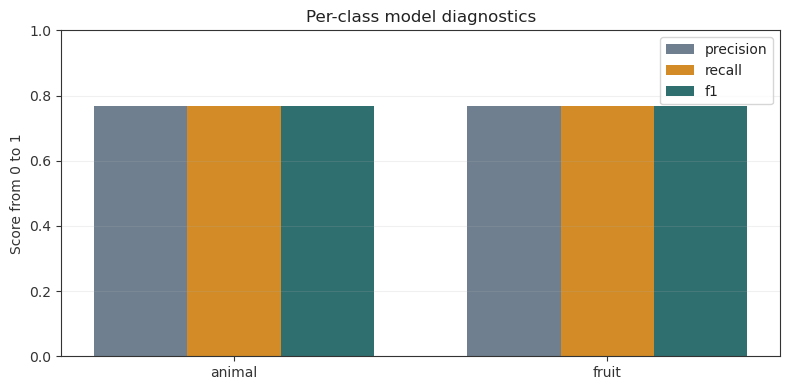

In [14]:
metric_rows = []
for index, class_name in enumerate(class_names):
    true_positive = matrix[index, index]
    false_positive = matrix[:, index].sum() - true_positive
    false_negative = matrix[index, :].sum() - true_positive
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
    metric_rows.append(
        {
            "class": class_name,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "test images": int(matrix[index, :].sum()),
        }
    )

metrics_df = pd.DataFrame(metric_rows).round(3)
display(metrics_df)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(metrics_df))
bar_width = 0.25
for offset, metric, color in [
    (-bar_width, "precision", "#6f7f8f"),
    (0, "recall", "#d28b26"),
    (bar_width, "f1", "#2f6f6f"),
]:
    ax.bar(x + offset, metrics_df[metric], width=bar_width, label=metric, color=color)
ax.set_xticks(x, metrics_df["class"])
ax.set_ylim(0, 1)
ax.set_title("Per-class model diagnostics")
ax.set_ylabel("Score from 0 to 1")
ax.legend()
ax.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()

### Which Test Images Were Difficult?

A useful model check is to look at individual test predictions, not only the overall score.

The chart below shows confidence on the held-back test set. The gallery shows some mistakes so students can discuss why they happened.

,path,actual,predicted,confidence,correct
0,data/images/fruit/fruit_043_kiwi.jpg,fruit,fruit,0.564,True
1,data/images/fruit/fruit_046_watermelon.jpg,fruit,fruit,0.556,True
2,data/images/animal/animal_057_rabbit.jpg,animal,fruit,0.570,False
3,data/images/fruit/fruit_096_lemon.jpg,fruit,animal,0.608,False
4,data/images/animal/animal_043_fox.jpg,animal,animal,0.544,True
5,data/images/animal/animal_068_sheep.jpg,animal,animal,0.536,True
6,data/images/animal/animal_070_lion.jpg,animal,animal,0.556,True
7,data/images/fruit/fruit_113_grapes.jpg,fruit,animal,0.558,False
8,data/images/fruit/fruit_057_pear.jpg,fruit,fruit,0.690,True
9,data/images/fruit/fruit_117_pear.jpg,fruit,fruit,0.556,True


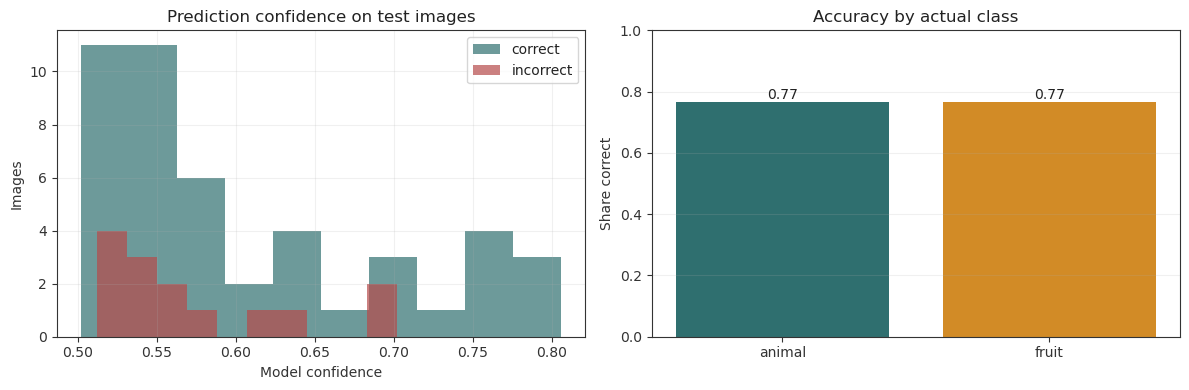

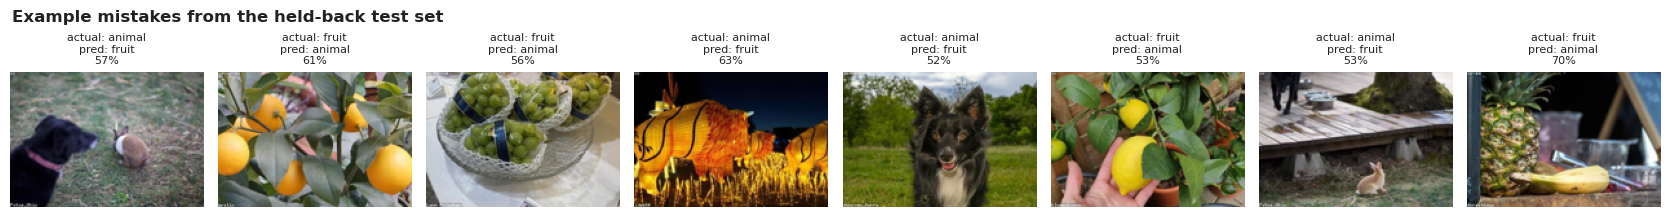

In [15]:
test_paths = [PROJECT_ROOT / path for path in split_info["test_files"]]
actual_labels = [path.parent.name for path in test_paths]
x_test = make_feature_matrix(test_paths)
test_probabilities = model.predict_proba(x_test)
predicted_indexes = np.argmax(test_probabilities, axis=1)
predicted_labels = [class_names[index] for index in predicted_indexes]
confidence = test_probabilities.max(axis=1)

prediction_df = pd.DataFrame(
    {
        "path": [str(path.relative_to(PROJECT_ROOT)) for path in test_paths],
        "actual": actual_labels,
        "predicted": predicted_labels,
        "confidence": confidence,
    }
)
prediction_df["correct"] = prediction_df["actual"] == prediction_df["predicted"]
display(prediction_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for correct_value, label, color in [
    (True, "correct", "#2f6f6f"),
    (False, "incorrect", "#b64b4b"),
]:
    subset = prediction_df[prediction_df["correct"] == correct_value]
    axes[0].hist(subset["confidence"], bins=10, alpha=0.7, label=label, color=color)
axes[0].set_title("Prediction confidence on test images")
axes[0].set_xlabel("Model confidence")
axes[0].set_ylabel("Images")
axes[0].legend()
axes[0].grid(alpha=0.18)

accuracy_by_class = (
    prediction_df.groupby("actual")["correct"].mean().reindex(class_names).reset_index()
)
axes[1].bar(
    accuracy_by_class["actual"],
    accuracy_by_class["correct"],
    color=[CLASS_COLORS.get(label, "#777777") for label in accuracy_by_class["actual"]],
)
axes[1].set_title("Accuracy by actual class")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Share correct")
axes[1].bar_label(axes[1].containers[0], fmt="%.2f")
axes[1].grid(axis="y", alpha=0.18)

plt.tight_layout()
plt.show()

mistakes = prediction_df[~prediction_df["correct"]].head(8)
if mistakes.empty:
    display(Markdown("No mistakes in this test split. That can happen, but always check for overfitting."))
else:
    fig, axes = plt.subplots(1, len(mistakes), figsize=(len(mistakes) * 2.1, 2.4))
    axes = np.atleast_1d(axes)
    for ax, (_, row) in zip(axes, mistakes.iterrows()):
        image_path = PROJECT_ROOT / row["path"]
        with Image.open(image_path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            ax.imshow(image.resize((150, 105)))
        ax.set_title(
            f"actual: {row['actual']}\npred: {row['predicted']}\n{row['confidence']:.0%}",
            fontsize=8,
        )
        ax.set_axis_off()
    fig.suptitle("Example mistakes from the held-back test set", x=0.01, ha="left", weight="bold")
    plt.tight_layout()
    plt.show()

## Step 8: Predict Unknown Images

The demo images are stored in `data/demo_inputs`, not inside the training folders.

That makes them a simple check that the program can accept an input image outside the training data and show a clear prediction.

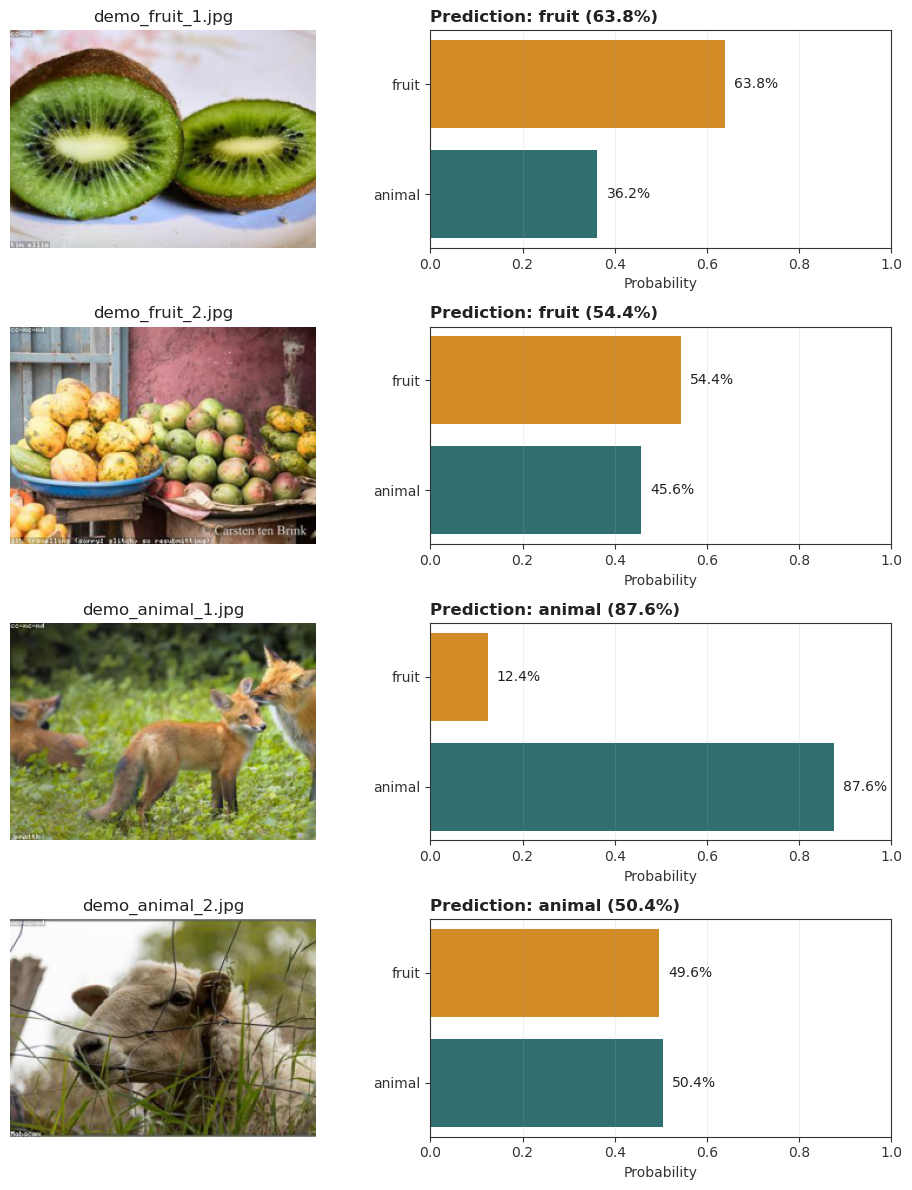

,image,prediction,confidence,score_animal,score_fruit
0,data/demo_inputs/demo_fruit_1.jpg,fruit,0.638,0.362,0.638
1,data/demo_inputs/demo_fruit_2.jpg,fruit,0.544,0.456,0.544
2,data/demo_inputs/demo_animal_1.jpg,animal,0.876,0.876,0.124
3,data/demo_inputs/demo_animal_2.jpg,animal,0.504,0.504,0.496


In [16]:
UNKNOWN_IMAGE_PATHS = [
    DEMO_DIR / "demo_fruit_1.jpg",
    DEMO_DIR / "demo_fruit_2.jpg",
    DEMO_DIR / "demo_animal_1.jpg",
    DEMO_DIR / "demo_animal_2.jpg",
]


def predict_image(image_path):
    features = extract_features(image_path).reshape(1, -1)
    probabilities = model.predict_proba(features)[0]
    best_index = int(np.argmax(probabilities))
    return {
        "image": str(Path(image_path).relative_to(PROJECT_ROOT)),
        "prediction": class_names[best_index],
        "confidence": probabilities[best_index],
        **{f"score_{class_name}": probability for class_name, probability in zip(class_names, probabilities)},
    }


def show_prediction(image_path, ax_image, ax_scores):
    result = predict_image(image_path)
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        ax_image.imshow(image.resize((260, 185)))
    ax_image.set_axis_off()
    ax_image.set_title(Path(image_path).name)

    scores = [result[f"score_{class_name}"] for class_name in class_names]
    colours = [CLASS_COLORS.get(class_name, "#777777") for class_name in class_names]
    ax_scores.barh(class_names, scores, color=colours)
    ax_scores.set_xlim(0, 1)
    ax_scores.set_xlabel("Probability")
    ax_scores.set_title(
        f"Prediction: {result['prediction']} ({result['confidence']:.1%})",
        loc="left",
        weight="bold",
    )
    for index, score in enumerate(scores):
        ax_scores.text(min(score + 0.02, 0.92), index, f"{score:.1%}", va="center")
    ax_scores.grid(axis="x", alpha=0.18)
    return result


fig, axes = plt.subplots(len(UNKNOWN_IMAGE_PATHS), 2, figsize=(10, 3 * len(UNKNOWN_IMAGE_PATHS)))
results = []
for row_index, image_path in enumerate(UNKNOWN_IMAGE_PATHS):
    results.append(show_prediction(image_path, axes[row_index, 0], axes[row_index, 1]))

plt.tight_layout()
plt.show()

unknown_results_df = pd.DataFrame(results)
display(unknown_results_df)

## Try Your Own Image

Put a new image somewhere in this project folder, then set `MY_IMAGE_PATH` to its path.

Example:

```python
MY_IMAGE_PATH = "my_test_images/apple_photo.jpg"
```

In [17]:
MY_IMAGE_PATH = ""

if MY_IMAGE_PATH:
    candidate_path = PROJECT_ROOT / MY_IMAGE_PATH
    if not candidate_path.exists():
        raise FileNotFoundError(candidate_path)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    custom_result = show_prediction(candidate_path, axes[0], axes[1])
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame([custom_result]))
else:
    print("Set MY_IMAGE_PATH to try a new picture.")

Set MY_IMAGE_PATH to try a new picture.


## What To Discuss

This project is deliberately small, so it is a good way to introduce the ideas without pretending the model is perfect.

Useful questions for students:

- Which images looked easiest or hardest?
- Did the model make more mistakes on fruit or animals?
- Did confidence always mean the answer was correct?
- What could happen if the dataset had wrong labels?
- What would improve the model: more data, cleaner data, better features, or a stronger model?

## Next Steps

After this notebook works, try one change at a time:

- increase or decrease `N_ESTIMATORS`
- change `TEST_SIZE` from `0.20` to `0.30`
- add a third class, such as `vehicle`
- replace the downloaded examples with reviewed company images
- compare this simple feature model with a transfer learning image model